<a href="https://colab.research.google.com/github/shimulkewu/Mechanistic_interpretability/blob/main/MNIST_img_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

x = torch.tensor(3.0, requires_grad=True)
y = x**2
x


tensor(3., requires_grad=True)

In [ ]:
y


tensor(9., grad_fn=<PowBackward0>)

In [ ]:
y.backward()

In [ ]:
x.grad

tensor(6.)

In [ ]:
import math

def dz_dx(x):
  return 2 * x * math.cos(x**2)
dz_dx(3)

-5.466781571308061

In [ ]:
x = torch.tensor(3.0, requires_grad=True)


In [ ]:
y = x ** 2

In [ ]:
z = torch.sin(y)

In [ ]:
x

tensor(3., requires_grad=True)

In [ ]:
y

tensor(9., grad_fn=<PowBackward0>)

In [ ]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [ ]:
z.backward()

In [ ]:
x.grad

tensor(-5.4668)

In [ ]:
import torch
x = torch.tensor(6.7) # Input feature
y = torch.tensor(0.0) # True label (binary)

w = torch.tensor(1.0) # Weight
b = torch.tensor(0.0) # Bias

In [ ]:
# Binary cross-entropy loss for scalar
def binary_cross_entropy_loss(prediction, trget):
  epsilon = 1e-8 # To prevent log(0)
  prediction = torch.clamp(prediction, epsilon, 1-epsilon)
  return -(trget * torch.log(prediction) + (1 - trget) * torch.log(1 - prediction))


In [ ]:
# Forward pass
z = w * x + b # weighted sum (linear part)
y_pred = torch.sigmoid(z) # Prediction probability

# Compute binary cross-entropy loss
loss = binary_cross_entropy_loss(y_pred, y)


NameError: name 'target' is not defined

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.keys()
mnist

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
 0           0       0       0       0       0       0       0       0       0   
 1           0       0       0       0       0       0       0       0       0   
 2           0       0       0       0       0       0       0       0       0   
 3           0       0       0       0       0       0       0       0       0   
 4           0       0       0       0       0       0       0       0       0   
 ...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 69995       0       0       0       0       0       0       0       0       0   
 69996       0       0       0       0       0       0       0       0       0   
 69997       0       0       0       0       0       0       0       0       0   
 69998       0       0       0       0       0       0       0       0       0   
 69999       0       0       0       0       0       0       0       0       0   
 
      

In [ ]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist


In [ ]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)
(10000, 28, 28)
5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 

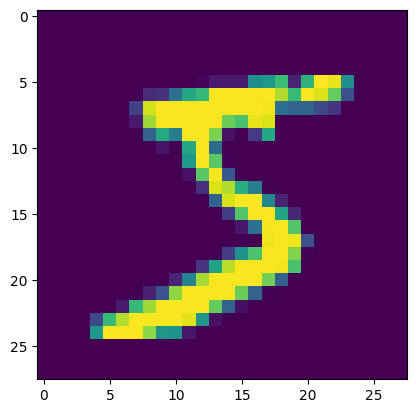

In [ ]:
import numpy as np
np.set_printoptions(linewidth= 200)
import matplotlib.pyplot as plt
plt.imshow(x_train[0])
print(x_train.shape)
print(x_test.shape)
print(y_train[0])
print(x_test[0])

In [ ]:
x_train,x_test = x_train/255.0,x_test/255.0

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(10,activation= tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
import tensorflow as tf

class mycallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs={}):
    if (logs.get('accuracy')>0.99):
      print("\nReached 99% accuracy so cancelling training!")
      self.model.stop_training=True
callbacks=mycallback()

In [16]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(10,activation= 'softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
import tensorflow as tf

# Load the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

model.fit(x_train, y_train, epochs=100, callbacks=[callbacks])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9411 - loss: 0.2004
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9742 - loss: 0.0823
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9834 - loss: 0.0532
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9878 - loss: 0.0379
Epoch 5/100
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0260
Reached 99% accuracy so cancelling training!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9904 - loss: 0.0304


In [9]:
import tensorflow as tf

# Load the data if not already loaded
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data
x_test = x_test / 255.0

model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0740


[0.07399480044841766, 0.9781000018119812]

In [10]:
import tensorflow as tf

# Load the data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0740
Test accuracy: 0.9781


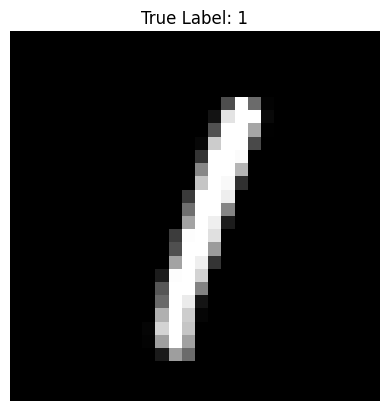

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted label: 1
Confidence: 0.9999


In [12]:
import numpy as np
import matplotlib.pyplot as plt

index = 5
sample_image = x_test[index]
true_label = y_test[index]

plt.imshow(sample_image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

input_data = np.expand_dims(sample_image, axis=0)
predictions = model.predict(input_data)
predicted_label = np.argmax(predictions)
confidence = np.max(predictions)

print(f"Predicted label: {predicted_label}")
print(f"Confidence: {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
My drawn digit is: 2


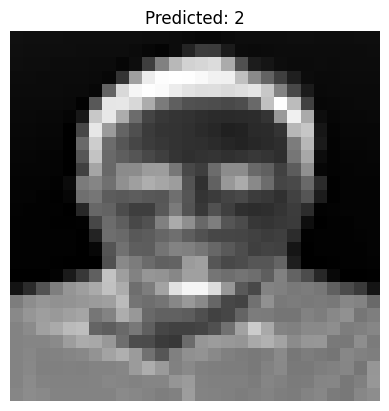

In [14]:
from PIL import Image

img = Image.open('/content/my-img.png').convert('L')   # grayscale
img = img.resize((28, 28))
img_array = np.array(img)

# Like MNIST data invert background (if needed)

img_array = 255 - img_array

# normalized  (btw 0-1)
img_array = img_array / 255.0

# added batch dimention
input_data = np.expand_dims(img_array, axis=0)

pred = model.predict(input_data)
pred_label = np.argmax(pred)
print(f"My drawn digit is: {pred_label}")

# explain what you inputed
plt.imshow(img_array, cmap='gray')
plt.title(f"Predicted: {pred_label}")
plt.axis('off')
plt.show()

In [20]:
# save
model.save('mnist_model.h5')

# save (if needed)
from tensorflow.keras.models import load_model
loaded_model = load_model('mnist_model.h5')
# then loaded_model.predict(...) use it..

In [21]:

batch = x_test[:10]
true_labels = y_test[:10]

preds = model.predict(batch)
pred_labels = np.argmax(preds, axis=1)

print("True labels :", true_labels)
print("Pred labels :", pred_labels)


errors = np.where(true_labels != pred_labels)[0]
print("Indices with errors:", errors)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
True labels : [7 2 1 0 4 1 4 9 5 9]
Pred labels : [8 4 9 8 8 3 8 6 8 8]
Indices with errors: [0 1 2 3 4 5 6 7 8 9]
